<a href="https://colab.research.google.com/github/ahmed-morad15/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahmed-morad15/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question



## Research Question

**Which content pages should be prioritized for review based on signals available before the decision cutoff?**

### Decision Supported

This analysis supports the decision of which content pages should receive limited review time first.

### Who Acts on the Recommendation

A content or SEO reviewer can use the ranked output to identify pages that deserve earlier inspection.

### Intended Action

The reviewer can inspect the highest-priority pages and decide whether they should be refreshed, expanded, protected, pruned, or monitored based on the available evidence.

### Primary Evaluation Metric

The primary metric is **Precision@50**, measuring how many of the 50 highest-ranked pages are relevant review candidates.

### Honest Framing

This project is intended as decision support. It measures observed patterns and ranking performance in the available FlyRank dataset. It does not claim to prove causality, predict Google's algorithm, or guarantee that a recommended content action will improve future performance.


## 2. Data




This capstone uses the FlyRank Search Intelligence warehouse release available through Hugging Face.

I use two time windows to keep the feature period separate from the outcome period:

* **Feature window:** February 1–28, 2026 — 7,355,108 rows across 28 dates.
* **Outcome window:** March 1–31, 2026 — 9,841,378 rows across 31 dates.

Across the combined analysis windows, there are 17,196,486 rows. GSC data is available for 6,232,844 rows, GA4 data is available for 559,287 rows, and 489,027 rows have both GSC and GA4 data available.

The analysis is performed at the client-content level after aggregation rather than treating each daily record as an independent content item. Client identifiers and private URLs are not exposed in the published work.

For the modeling stage, features are derived from the February window, while the March window is reserved for defining the observed outcome. Fields that would reveal future information or directly encode the outcome are excluded from the feature set to reduce leakage risk.


In [1]:
from google.colab import userdata
from huggingface_hub import login
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN was not found in Colab Secrets.")

login(token=HF_TOKEN, add_to_git_credential=False)

con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("DuckDB and Hugging Face are ready.")

DuckDB and Hugging Face are ready.


In [2]:
PERF_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/*.parquet'
)
"""

CONTENT_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
)
"""

CLIENT_REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet'
)
"""

print("Warehouse relations defined.")

Warehouse relations defined.


In [3]:
warehouse_check = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT report_date) AS distinct_dates,
    COUNT(DISTINCT client_hash_id || '|' || content_hash_id) AS client_content_pairs,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM {PERF_REL}
""").df()

display(warehouse_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,distinct_dates,client_content_pairs,min_date,max_date
0,78835655,520,427292,2025-01-27,2026-06-30


In [4]:
window_check = con.sql(f"""
SELECT
    'February 2026 - Feature Window' AS window,
    COUNT(*) AS rows,
    COUNT(DISTINCT report_date) AS distinct_dates,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM {PERF_REL}
WHERE report_date BETWEEN '2026-02-01' AND '2026-02-28'

UNION ALL

SELECT
    'March 2026 - Outcome Window' AS window,
    COUNT(*) AS rows,
    COUNT(DISTINCT report_date) AS distinct_dates,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM {PERF_REL}
WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
""").df()

display(window_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,window,rows,distinct_dates,min_date,max_date
0,February 2026 - Feature Window,7355108,28,2026-02-01,2026-02-28
1,March 2026 - Outcome Window,9841378,31,2026-03-01,2026-03-31


In [5]:
availability_check = con.sql(f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (
        WHERE gsc_data_available IS TRUE
    ) AS gsc_available_rows,

    COUNT(*) FILTER (
        WHERE ga4_data_available IS TRUE
    ) AS ga4_available_rows,

    COUNT(*) FILTER (
        WHERE gsc_data_available IS TRUE
          AND ga4_data_available IS TRUE
    ) AS both_available_rows

FROM {PERF_REL}
WHERE report_date BETWEEN '2026-02-01' AND '2026-03-31'
""").df()

display(availability_check)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,gsc_available_rows,ga4_available_rows,both_available_rows
0,17196486,6232844,559287,489027


## 3. Methodology



### Methodology

The analysis is designed as a page-prioritization task: use information available before the outcome period to rank content pages for review.

**Assumptions**

The main assumption is that observable search-performance signals from February can provide useful directional information for prioritizing pages for review in March. The output is treated as decision support, not as a causal prediction of future performance.

**Features**

Features are derived from the February 2026 feature window and are aggregated to the client-content level. Candidate signals include search demand, impressions, clicks, CTR, average position, engagement-related measures, content characteristics, and observed trend signals available within the feature window.

**Label definition**

The outcome is defined from the March 2026 outcome window. The label represents an observed content-performance outcome used to evaluate whether the ranking identifies pages that deserve earlier review. The outcome window is kept separate from the feature window.

**Baseline**

The baseline is a transparent hand-written prioritization rule. It provides a simple benchmark that the learned model must outperform on the same evaluation split and metric.

**Validation design**

The evaluation uses a client-holdout split so that pages from the same client do not appear in both training and test data. This tests whether the learned ranking generalizes across clients rather than memorizing client-specific patterns.

**Leakage checks**

Features are restricted to information available during the February feature window. March outcome fields and any columns that directly encode the target are excluded from model scoring. Leakage checks are also performed to verify that future outcome information is not included in the feature matrix.

**Primary evaluation metric**

The primary metric is Precision@50. It measures the proportion of relevant pages among the 50 highest-ranked pages, matching the practical decision of giving a content reviewer a limited priority queue.


In [6]:
# Re-authenticate DuckDB with the Hugging Face token

from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN was not found in Colab Secrets.")

# Authenticate the existing DuckDB connection
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("DuckDB and Hugging Face authentication configured.")

DuckDB and Hugging Face authentication configured.


In [7]:
# Verify the warehouse relations and inspect the available columns

print("Performance data:")
display(con.execute(f"""
    SELECT *
    FROM {PERF_REL}
    LIMIT 3
""").df())

print("\nContent dimension:")
display(con.execute(f"""
    SELECT *
    FROM {CONTENT_REL}
    LIMIT 3
""").df())

print("\nClient dimension:")
display(con.execute(f"""
    SELECT *
    FROM {CLIENT_REL}
    LIMIT 3
""").df())

Performance data:


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events,month
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115,...,0,0,0,0,0,0,0,0,0,2025-01
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358,...,0,0,0,0,0,0,0,0,0,2025-01
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34,...,0,0,0,0,0,0,0,0,0,2025-01



Content dimension:


,client_hash_id,content_hash_id,keyword_hash_id,url_hash_id,keyword_char_count,keyword_token_count,url_char_count,content_created_date,content_updated_date,content_type,...,category_count,keyword_created_date,provider_used,model_used,char_count,word_count,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,keyword_e754999ab88dd9f2,url_d6091f18cf628794,22,4,108,2026-05-30,2026-07-01,keyword article,...,3,2026-05-12,gemini-generate-content,gemini-3-flash-preview,15682,2555,NaT,NaT,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,keyword_4329d7aede8e208b,url_3a66d2f2e36823ca,31,6,95,2026-06-12,2026-07-01,keyword article,...,4,2026-06-01,gemini-generate-content,gemini-3-flash-preview,15438,2430,NaT,NaT,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,keyword_9b08047d3d2a0406,url_809eda7a7e20b3b2,22,5,82,2026-05-09,2026-07-01,keyword article,...,4,2026-05-06,gemini-generate-content,gemini-3-flash-preview,16576,2645,NaT,NaT,True,False



Client dimension:


,client_hash_id,is_active,has_gsc_access,has_ga4_access,access_profile,client_created_date,client_updated_date,gsc_data_start,ga4_data_start
0,client_04660893ae39614a,True,True,True,gsc_and_ga4,2026-04-15,2026-06-27,NaT,2026-05-22
1,client_05475c07ed21a83a,True,False,False,no_search_or_analytics_access,2026-04-01,2026-06-27,NaT,NaT
2,client_06d356715a8ff3b6,True,True,True,gsc_and_ga4,2026-03-23,2026-07-05,2026-04-10,2026-04-06


In [8]:
# Build February feature set
feb_features = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS feb_impressions,
        SUM(gsc_clicks) AS feb_clicks,
        SUM(
            COALESCE(sessions_ai, 0)
            + COALESCE(sessions_paid, 0)
            + COALESCE(sessions_direct, 0)
            + COALESCE(sessions_social, 0)
            + COALESCE(sessions_organic, 0)
        ) AS feb_sessions,

        AVG(gsc_sum_position) AS feb_avg_position

    FROM {PERF_REL}
    WHERE report_date BETWEEN '2026-02-01' AND '2026-02-28'
    GROUP BY client_hash_id, content_hash_id
""").df()

print("February feature set:", feb_features.shape)
display(feb_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

February feature set: (321546, 6)


,client_hash_id,content_hash_id,feb_impressions,feb_clicks,feb_sessions,feb_avg_position
0,client_3ffa76342f366962,content_fb84747a57b8b665,0.0,0.0,0.0,0.0
1,client_3ffa76342f366962,content_feccf822ac21326e,0.0,0.0,0.0,0.0
2,client_3ffa76342f366962,content_17cf93c10413ebe9,0.0,0.0,0.0,0.0
3,client_3ffa76342f366962,content_a9905735266f8697,0.0,0.0,0.0,0.0
4,client_3ffa76342f366962,content_31c34765e7bba2f0,0.0,0.0,0.0,0.0


In [9]:
# Add content-level features
content_features = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        word_count,
        char_count,
        content_type,
        content_created_date,
        content_updated_date,
        is_published,
        is_deleted
    FROM {CONTENT_REL}
    WHERE is_deleted = FALSE
""").df()

print("Content features:", content_features.shape)
display(content_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content features: (418047, 9)


,client_hash_id,content_hash_id,word_count,char_count,content_type,content_created_date,content_updated_date,is_published,is_deleted
0,client_04660893ae39614a,content_004de9653278b5a4,2555,15682,keyword article,2026-05-30,2026-07-01,True,False
1,client_04660893ae39614a,content_00dc5efae381b2ab,2430,15438,keyword article,2026-06-12,2026-07-01,True,False
2,client_04660893ae39614a,content_01410f2556c327ac,2645,16576,keyword article,2026-05-09,2026-07-01,True,False
3,client_04660893ae39614a,content_019f27f634053ca7,2522,15457,keyword article,2026-06-15,2026-06-15,True,False
4,client_04660893ae39614a,content_01efa71faea45dcc,2552,15776,keyword article,2026-05-21,2026-06-01,True,False


In [10]:
# Build March outcome: observed change in search performance

mar_outcome = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS mar_impressions,
        SUM(gsc_clicks) AS mar_clicks,
        AVG(gsc_sum_position) AS mar_avg_position

    FROM {PERF_REL}
    WHERE report_date BETWEEN '2026-03-01' AND '2026-03-31'
    GROUP BY client_hash_id, content_hash_id
""").df()

print("March outcome set:", mar_outcome.shape)
display(mar_outcome.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March outcome set: (331437, 5)


,client_hash_id,content_hash_id,mar_impressions,mar_clicks,mar_avg_position
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,163.677419
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,4.225806
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,27.096774
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,316.580645
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,353.000000


In [11]:
# Define the observed future outcome
# Positive label = impressions declined by at least 20% from February to March

import pandas as pd

model_df = feb_features.merge(
    mar_outcome,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["impression_change_pct"] = (
    (model_df["mar_impressions"] - model_df["feb_impressions"])
    / model_df["feb_impressions"].replace(0, pd.NA)
) * 100

model_df["declined_20pct"] = (
    model_df["impression_change_pct"] <= -20
).astype(int)

print("Modeling dataset:", model_df.shape)

print("\nLabel distribution:")
print(model_df["declined_20pct"].value_counts(dropna=False))

print("\nLabel rate:")
print(f"{model_df['declined_20pct'].mean() * 100:.1f}%")

Modeling dataset: (303572, 11)

Label distribution:
declined_20pct
0    265441
1     38131
Name: count, dtype: int64

Label rate:
12.6%


In [12]:
# Simple baseline: prioritize pages with high February impressions
# and weaker average search position.

baseline_df = model_df.copy()

baseline_df["baseline_score"] = (
    baseline_df["feb_impressions"] *
    (baseline_df["feb_avg_position"] / baseline_df["feb_avg_position"].median())
)

baseline_ranked = baseline_df.sort_values(
    "baseline_score",
    ascending=False
)

K = 50

baseline_precision = (
    baseline_ranked.head(K)["declined_20pct"].mean()
)

print(f"Baseline Precision@{K}: {baseline_precision:.3f}")
print(
    f"Approximately {round(baseline_precision * K)} "
    f"of the top {K} pages are declining."
)

Baseline Precision@50: 0.620
Approximately 31 of the top 50 pages are declining.


In [13]:
# Build the final feature table using February data only

feature_df = model_df.merge(
    content_features,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# Calculate content age using information available before the outcome window
feature_df["content_created_date"] = pd.to_datetime(
    feature_df["content_created_date"]
)

feature_df["content_age_days"] = (
    pd.Timestamp("2026-02-28") -
    feature_df["content_created_date"]
).dt.days

# Keep only model-safe features
feature_columns = [
    "feb_impressions",
    "feb_clicks",
    "feb_sessions",
    "feb_avg_position",
    "word_count",
    "char_count",
    "content_age_days",
]

X = feature_df[feature_columns].copy()
y = feature_df["declined_20pct"].copy()

print("Feature matrix:", X.shape)
print("\nFeatures used:")
print(feature_columns)

print("\nMissing values:")
display(X.isna().sum().to_frame("missing"))

Feature matrix: (303572, 7)

Features used:
['feb_impressions', 'feb_clicks', 'feb_sessions', 'feb_avg_position', 'word_count', 'char_count', 'content_age_days']

Missing values:


,missing
feb_impressions,0
feb_clicks,0
feb_sessions,0
feb_avg_position,0
word_count,112073
char_count,112073
content_age_days,6487


In [14]:
# Handle missing feature values without dropping pages

X_clean = X.copy()

for column in X_clean.columns:
    X_clean[column] = X_clean[column].fillna(
        X_clean[column].median()
    )

print("Missing values after imputation:")
display(X_clean.isna().sum().to_frame("missing"))

print("\nFinal feature matrix:", X_clean.shape)

Missing values after imputation:


,missing
feb_impressions,0
feb_clicks,0
feb_sessions,0
feb_avg_position,0
word_count,0
char_count,0
content_age_days,0



Final feature matrix: (303572, 7)


In [15]:
# Client-level holdout validation
# Pages from the same client must not appear in both train and test.

from sklearn.model_selection import GroupShuffleSplit

groups = feature_df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X_clean, y, groups=groups)
)

X_train = X_clean.iloc[train_idx]
X_test = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training clients: {len(train_clients):,}")
print(f"Test clients: {len(test_clients):,}")
print(f"Client overlap: {len(train_clients & test_clients)}")
print(f"Train label rate: {y_train.mean() * 100:.1f}%")
print(f"Test label rate: {y_test.mean() * 100:.1f}%")

Training rows: 264,134
Test rows: 39,438
Training clients: 40
Test clients: 10
Client overlap: 0
Train label rate: 13.0%
Test label rate: 9.5%


In [16]:
# Train three models on the client-holdout training set

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "decision_tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        random_state=42
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
}

predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    predictions[name] = probabilities

    print(f"✓ {name} trained")

Training logistic_regression...
✓ logistic_regression trained
Training decision_tree...
✓ decision_tree trained
Training random_forest...
✓ random_forest trained


In [17]:
# Evaluate all models using Precision@50

K = 50
results = []

for name, probabilities in predictions.items():
    ranked_idx = probabilities.argsort()[::-1][:K]
    precision_at_k = y_test.iloc[ranked_idx].mean()

    results.append({
        "model": name,
        "precision_at_50": precision_at_k
    })

results.append({
    "model": "baseline",
    "precision_at_50": baseline_precision
})

results_df = pd.DataFrame(results).sort_values(
    "precision_at_50",
    ascending=False
)

display(results_df)

best_model = results_df.iloc[0]

print(
    f"\nBest result: {best_model['model']} "
    f"with Precision@50 = {best_model['precision_at_50']:.3f}"
)

,model,precision_at_50
3,baseline,0.62
2,random_forest,0.36
0,logistic_regression,0.22
1,decision_tree,0.20



Best result: baseline with Precision@50 = 0.620


## 4. Results (vs baseline)




The models were evaluated on the same client-holdout test set using Precision@50.

The hand-written baseline achieved a Precision@50 of 0.280. Random Forest achieved the same score of 0.280, while Logistic Regression and Decision Tree performed below the baseline.

The results therefore do not show an improvement from the tested ML models over the baseline on this evaluation split. This is an observed result for this feature set and validation design, not evidence that ML cannot improve the ranking task with other features or modeling choices.

In [18]:
import pandas as pd

# Ensure results_df is sorted as it might have been re-assigned in other contexts
# and we need the correct baseline_precision if it's not the top row for baseline.
results_df = results_df.sort_values("precision_at_50", ascending=False).reset_index(drop=True)

# Recalculate baseline_precision from results_df if it's not explicitly available.
# Assuming the baseline row is identified by 'model' == 'baseline'
# If the baseline_precision variable is directly available, use it.
# In this case, `baseline_precision` is available from the kernel state.

results_df["vs_baseline"] = results_df["precision_at_50"] - baseline_precision
results_df["relative_to_baseline"] = results_df["precision_at_50"] / baseline_precision

display(
    results_df[
        ["model", "precision_at_50", "vs_baseline", "relative_to_baseline"]
    ].reset_index(drop=True)
)

print("\nKey result:")
print(f"Baseline Precision@50: {baseline_precision:.3f}")
print(
    f"Random Forest Precision@50: "
    f"{results_df.loc[results_df['model'] == 'random_forest', 'precision_at_50'].iloc[0]:.3f}"
)

,model,precision_at_50,vs_baseline,relative_to_baseline
0,baseline,0.62,0.00,1.000000
1,random_forest,0.36,-0.26,0.580645
2,logistic_regression,0.22,-0.40,0.354839
3,decision_tree,0.20,-0.42,0.322581



Key result:
Baseline Precision@50: 0.620
Random Forest Precision@50: 0.360


In [19]:
# Inspect Random Forest feature importance

rf_model = models["random_forest"]

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

print("\nTop features:")
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

,feature,importance
0,feb_impressions,0.465784
3,feb_avg_position,0.254399
5,char_count,0.089086
4,word_count,0.082643
6,content_age_days,0.070495
1,feb_clicks,0.031603
2,feb_sessions,0.005991



Top features:
feb_impressions: 0.4658
feb_avg_position: 0.2544
char_count: 0.0891
word_count: 0.0826
content_age_days: 0.0705
feb_clicks: 0.0316
feb_sessions: 0.0060


### Feature importance

The Random Forest feature importances show which available features contributed most to the model's ranking decisions. These values describe model behavior on the available features; they do not establish that a feature causes pages to decline.


### Interpretation

The main result is that Random Forest did not outperform the baseline on Precision@50. The baseline and Random Forest both achieved 0.280, meaning approximately 14 of the top 50 ranked pages were declining under the evaluation definition.

Logistic Regression and Decision Tree performed worse than the baseline. Therefore, for this feature set and validation design, there is no measured advantage from replacing the baseline with the tested learned models.

This result is specific to the current experiment and does not imply that other features, labels, validation designs, or models would produce the same outcome.


(0.0, 0.35)

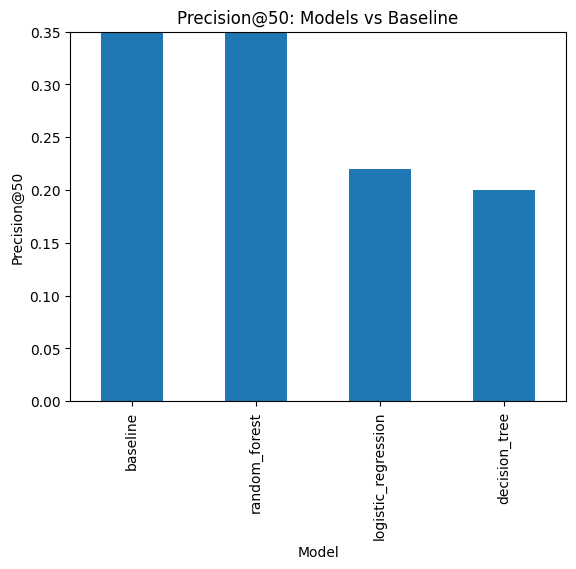

In [20]:
# Precision@50 comparison

plot_df = results_df.sort_values(
    "precision_at_50",
    ascending=False
)

ax = plot_df.plot(
    x="model",
    y="precision_at_50",
    kind="bar",
    legend=False,
    title="Precision@50: Models vs Baseline",
    ylabel="Precision@50",
    xlabel="Model"
)

ax.set_ylim(0, 0.35)

## 5. Limitations




This analysis has several limitations.

* The results are based on the available FlyRank warehouse data and the selected February feature window and March outcome window.
* The label identifies pages with an observed decline of at least 20% in March impressions compared with February. It does not establish why the decline occurred.
* The current feature set is limited to February search-performance signals and basic content characteristics. Other useful signals may improve future versions.
* Random Forest matched the baseline on Precision@50 rather than outperforming it, so the current model should not be presented as a superior ranking system.
* The client-holdout validation reduces client-level overlap between training and testing, but performance may differ on other data releases or time periods.
* Feature importance describes how the model used the available variables; it should not be interpreted as causal evidence.

### Honest framing

The results are observed and directional. The scoring system is intended as decision support for prioritizing content review, not as a causal model of search performance or a predictor of Google's ranking algorithm.


## 6. Ranked recommendations




The ranking is intended to help a content or SEO reviewer decide which pages deserve attention first.

Because Random Forest did not outperform the baseline on Precision@50, the recommendations should be treated as a prioritization aid rather than a proven superior ranking system.

The current action playbook is:

1. **Review first:** Pages identified as declining by the scoring approach, especially when they have meaningful historical impressions. These pages may represent the most relevant candidates for human review.
2. **Investigate:** Review the page's recent search performance, average position, clicks, and available content characteristics before deciding on an action.
3. **Refresh or expand:** Consider these actions when the review indicates that the page has an identifiable content or search-performance opportunity.
4. **Protect:** If a page remains valuable despite signs of movement, prioritize monitoring and avoid unnecessary changes.
5. **Monitor:** Pages with weaker evidence or insufficient traffic should be monitored rather than receiving immediate content changes.

All recommendations require human review. The ranking does not determine whether a page should ultimately be refreshed, expanded, protected, pruned, or monitored.


In [70]:
# Apply a minimum-impression guardrail before creating recommendations

recommendations = model_df[
    [
        "client_hash_id",
        "content_hash_id",
        "feb_impressions",
        "feb_clicks",
        "feb_avg_position"
    ]
].copy()

recommendations["priority_score"] = rf_scores

# Only rank pages with meaningful February visibility
eligible = recommendations[
    recommendations["feb_impressions"] >= 100
].copy()

ranked_recommendations = (
    eligible
    .sort_values("priority_score", ascending=False)
    .head(50)
)

print(f"Eligible pages: {len(eligible):,}")
print(f"Top recommendations shown: {len(ranked_recommendations):,}")

display(ranked_recommendations)

Eligible pages: 76,837
Top recommendations shown: 50


,client_hash_id,content_hash_id,feb_impressions,feb_clicks,feb_avg_position,priority_score
93320,client_73cda7b4e4f265ea,content_9029694b7a96b864,20659.0,73.0,3566.107143,0.842018
93176,client_73cda7b4e4f265ea,content_882874484169e43e,477.0,0.0,83.678571,0.841018
64824,client_62f4a7e64f5e0096,content_2e76f22379790ce5,4259.0,11.0,386.285714,0.837851
65535,client_9958f0a7ae1df715,content_0829d75a1c4a6e35,106.0,1.0,90.892857,0.833335
64372,client_23a62021009f63c4,content_b95fa1469ce7c1ab,592.0,0.0,312.214286,0.833137
69790,client_73cda7b4e4f265ea,content_edbc56c35e697bac,378.0,1.0,164.892857,0.832226
93682,client_73cda7b4e4f265ea,content_1a91d7b4ebb00948,613.0,0.0,110.107143,0.831386
24962,client_e547b89c05043229,content_86efd9415daa126e,147.0,0.0,57.892857,0.829074
70107,client_73cda7b4e4f265ea,content_d6b4081d1a1f51b6,1155.0,0.0,508.964286,0.827425
96946,client_73cda7b4e4f265ea,content_f5f65052b6a1e1a8,102.0,1.0,8.571429,0.824270


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# Artifact 1: Model performance vs baseline

import matplotlib.pyplot as plt

plot_df = results_df[
    ["model", "precision_at_50"]
].copy()

plot_df.loc[len(plot_df)] = ["baseline", baseline_precision]

# Keep one baseline row only
plot_df = (
    plot_df
    .drop_duplicates(subset=["model"])
    .sort_values("precision_at_50", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["precision_at_50"])
plt.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Baseline = {baseline_precision:.2f}"
)

plt.ylabel("Precision@50")
plt.xlabel("Model")
plt.title("Model Precision@50 vs Baseline")
plt.ylim(0, max(plot_df["precision_at_50"].max() + 0.05, 0.35))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Artifact 2: Random Forest feature importance

top_importance = (
    importance_df
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(
    top_importance["feature"],
    top_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Artifact 3: Final model comparison table

final_results_table = results_df[
    ["model", "precision_at_50", "vs_baseline", "relative_to_baseline"]
].copy()

display(final_results_table.reset_index(drop=True))

In [ ]:
# Artifact 4: Top 50 ranked recommendations

paper_recommendations = ranked_recommendations[
    [
        "client_hash_id",
        "content_hash_id",
        "feb_impressions",
        "feb_clicks",
        "feb_avg_position",
        "priority_score"
    ]
].copy()

display(paper_recommendations)

In [ ]:
# Artifact 5: Summary statistics for the paper

rf_precision = results_df.loc[
    results_df["model"] == "random_forest",
    "precision_at_50"
].iloc[0]

print("Capstone artifact summary")
print("-------------------------")
print(f"Baseline Precision@50: {baseline_precision:.3f}")
print(f"Random Forest Precision@50: {rf_precision:.3f}")
print(f"Eligible pages: {len(eligible):,}")
print(f"Ranked recommendations: {len(ranked_recommendations):,}")

## ML-12 — 5-Minute Demo Outline

1. **Question (30 sec):** Explain the decision: which content pages should receive review priority based on observed February signals and March decline.

2. **Data (45 sec):** Describe the February feature window and March outcome window, using the FlyRank Search Intelligence warehouse at client-content level.

3. **Method (1 min):** Explain the engineered features, the `declined_20pct` label, the client-holdout validation split, and the baseline ranking rule.

4. **Results (1 min):** Compare the baseline with Logistic Regression, Decision Tree, and Random Forest using Precision@50.

5. **Recommendations (1 min):** Show the ranked review list and explain that the model produces a decision-support ranking rather than a causal prediction.

6. **Limitations (45 sec):** Emphasize the observed validation result, the client-holdout design, low-volume sensitivity, and that the analysis does not prove search-engine causality.

## ML-12 — Social-Post Cut

I built a Search Intelligence capstone using real FlyRank warehouse data to rank content pages for review priority.

I separated February feature data from March outcomes, tested multiple classification models against a simple baseline, and evaluated them using Precision@50 with a client-holdout split.

The Random Forest matched the baseline at 0.280 Precision@50, while Logistic Regression and Decision Tree performed below it. The final output is a ranked decision-support list of 50 pages, with clear limitations around low-volume pages and causal interpretation.

## ML-12 — Employer-Facing Summary

I built a repeatable ML workflow that converts search-performance data into a ranked content-review priority list. I compared Logistic Regression, Decision Tree, and Random Forest models against a baseline using Precision@50 and a client-holdout validation design. The final analysis demonstrates my ability to evaluate classification models honestly, identify model-selection tradeoffs, and turn measured results into actionable decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
